# <b>  lec01.딥러닝 기초 클래스

## IRIST 데이터 로드 및 분류모델 학습, 평가

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#-----------------------------------------------------------------------------------  교차검증
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import accuracy_score,      f1_score

import warnings
warnings.filterwarnings('ignore')

sns.set()

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)



In [2]:
from sklearn.datasets import load_iris
X, y = load_iris(as_frame=True , return_X_y=True)
X.columns = ["sl","sw","pl","pw"]
X.head(2)

,sl,sw,pl,pw
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2


In [3]:
X80,X20, y80, y20 = train_test_split(X, y, test_size=0.2,random_state=4878, shuffle=True, stratify=y)
model = RandomForestClassifier(random_state=5787)
model.fit(X80, y80)
pred = model.predict(X20)

acc = accuracy_score(y20, pred)
f1  = f1_score(y20, pred, average="macro")
print(f"acc: {acc:.4f}  f1 : {f1:.4f}") 


acc: 0.9667  f1 : 0.9666


## 딥러닝 라이브러리 호출

In [4]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

## 딥러닝 모델 점수

In [5]:
model = Sequential([
    Dense(units = 10, activation = 'relu', input_dim = 4),   # input layer (입력층 산출물(임의숫자)), 활성화함수, input의 갯수)
    Dense(16, activation = 'relu'),   # hidden layer1  (임의 숫자)
    Dense(24, activation = 'relu'),   # hidden layer2  (임의 숫자)
    Dense(8, activation = 'relu'),   # hidden layer3  (임의 숫자)
    Dense(3, activation = 'softmax')    # output layer1 (아웃풋 분류의 갯수:3)
])

In [6]:
model.compile(loss = 'sparse_categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │              50 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 24)                  │             408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 8)                   │             200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 3)                   │              27 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 861 (3.36 KB)

 Trainable params: 861 (3.36 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
res = model.fit(X80, y80, epochs = 50, validation_data = (X20,y20))
res
loss, acc = model.evaluate(X20, y20)
print(f"acc: {acc:.4f}, loss:{loss:.4f}")

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.3333 - loss: 1.5066 - val_accuracy: 0.3333 - val_loss: 1.4179
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3333 - loss: 1.3309 - val_accuracy: 0.3333 - val_loss: 1.2706
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3333 - loss: 1.1987 - val_accuracy: 0.3333 - val_loss: 1.1570
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3333 - loss: 1.1048 - val_accuracy: 0.3333 - val_loss: 1.0821
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3417 - loss: 1.0357 - val_accuracy: 0.3333 - val_loss: 1.0209
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3667 - loss: 0.9830 - val_accuracy: 0.4667 - val_loss: 0.9749
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5750 - loss: 0.9438 - val_accuracy: 0.6000 - val_loss: 0.9359
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6583 - loss: 0.9114 - val_accuracy: 0.6667 - val_loss: 0.8994


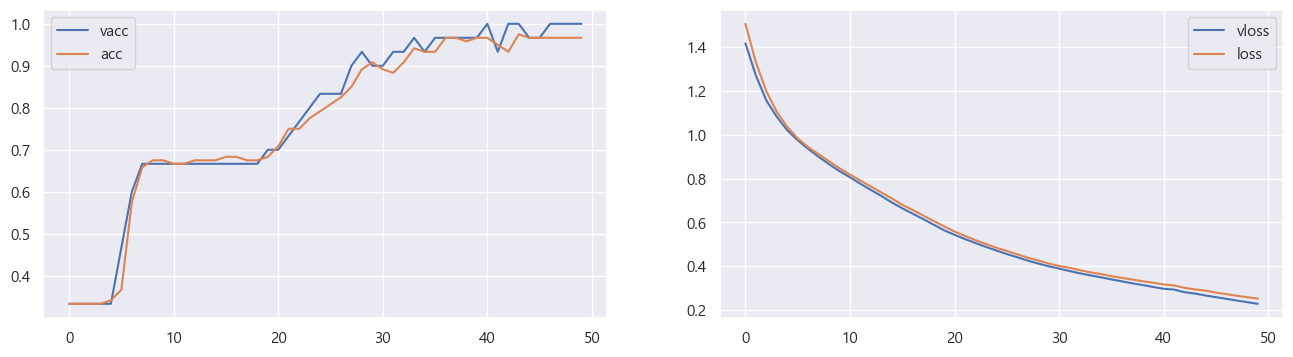

In [9]:
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
vacc = res.history["val_accuracy"]
acc  = res.history["accuracy"]
plt.plot(range(50), vacc , label="vacc")
plt.plot(range(50), acc  , label="acc")
plt.legend()
plt.subplot(1,2,2)
vloss = res.history["val_loss"]
loss = res.history["loss"]
plt.plot(range(50),vloss , label="vloss")
plt.plot(range(50),loss  , label="loss")
plt.legend()
plt.show()

In [2]:
! pip show keras

Name: keras
Version: 3.12.0
Summary: Multi-backend Keras
Home-page: 
Author: 
Author-email: Keras team <keras-users@googlegroups.com>
License: Apache License 2.0
Location: c:\it\workspace_python\.venv\lib\site-packages
Requires: absl-py, h5py, ml-dtypes, namex, numpy, optree, packaging, rich
Required-by: tensorflow
